# IDS Project — Notebook 1: EDA & Preprocessing
**Dataset:** CICIDS 2017  
**Hardware:** i9-13950HX + RTX 3500 Ada

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pickle

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


## 2. Load All CSV Files

In [2]:
DATA_DIR = '.'

csv_files = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
]

dfs = []
for f in csv_files:
    path = os.path.join(DATA_DIR, f)
    df_temp = pd.read_csv(path, low_memory=False)
    print(f'{f}: {df_temp.shape}')
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df.shape}')

Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)

Combined shape: (2830743, 79)


## 3. Basic Inspection

In [3]:
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

Shape: (2830743, 79)

Column names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,...,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4,4,4,4.0000,0.0000,4,4,...,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,...,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,...,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,...,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,...,0.0000,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN


In [5]:
df.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

## 4. Label Distribution

In [6]:
label_counts = df['Label'].value_counts()
print('Attack type counts:')
print(label_counts)
print(f'\nTotal classes: {label_counts.shape[0]}')

Attack type counts:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total classes: 15


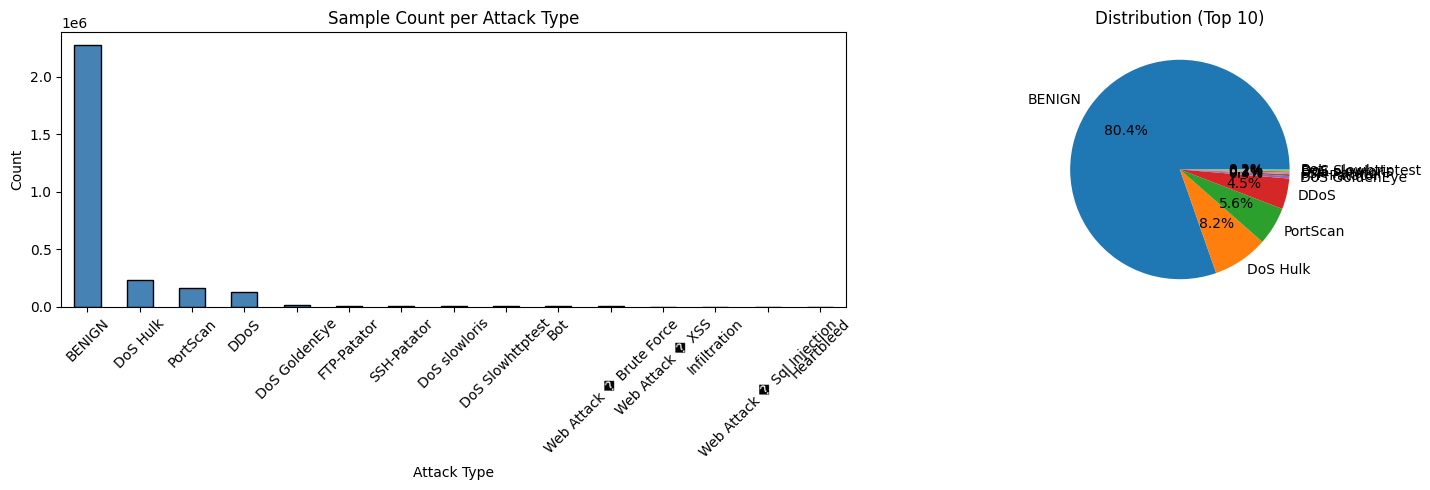

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Count per Attack Type')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

label_counts.head(10).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Distribution (Top 10)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

## 5. Missing Values & Infinite Values

In [8]:
null_counts = df.isnull().sum()
print('Columns with nulls:')
print(null_counts[null_counts > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print('\nColumns with infinity values:')
print(inf_counts[inf_counts > 0])

Columns with nulls:
Flow Bytes/s    1358
dtype: int64

Columns with infinity values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(df)
df.dropna(inplace=True)
print(f'Dropped {rows_before - len(df)} rows with NaN/Inf')
print(f'Remaining rows: {len(df)}')

Dropped 2867 rows with NaN/Inf
Remaining rows: 2827876


## 6. Statistical Summary

In [10]:
df[numeric_cols].describe().T.sort_values('std', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2827876.0000,14800654.1549,33667504.6592,-13.0000,155.0000,31338.0000,3239368.2500,119999998.0000
Fwd IAT Total,2827876.0000,14497645.0694,33589658.9177,0.0000,0.0000,45.0000,1259458.0000,120000000.0000
Bwd IAT Total,2827876.0000,9903861.0628,28749449.9257,0.0000,0.0000,3.0000,99271.5000,120000000.0000
Flow Bytes/s,2827876.0000,1491719.0643,25940155.6699,-261000000.0000,119.2924,4586.6008,166666.6667,2071000000.0000
Fwd IAT Max,2827876.0000,9052106.6075,24539897.6494,0.0000,0.0000,45.0000,956851.5000,120000000.0000
Flow IAT Max,2827876.0000,9191784.8330,24470186.6700,-13.0000,124.0000,30875.0000,2482934.2500,120000000.0000
Idle Max,2827876.0000,8704568.0433,24377663.2766,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Mean,2827876.0000,8324467.7172,23640569.6910,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Min,2827876.0000,7928060.6202,23373897.5395,0.0000,0.0000,0.0000,0.0000,120000000.0000
Fwd Header Length.1,2827876.0000,-26023.7947,21063527.2204,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000


## 7. Correlation Heatmap (Top 20 Features)

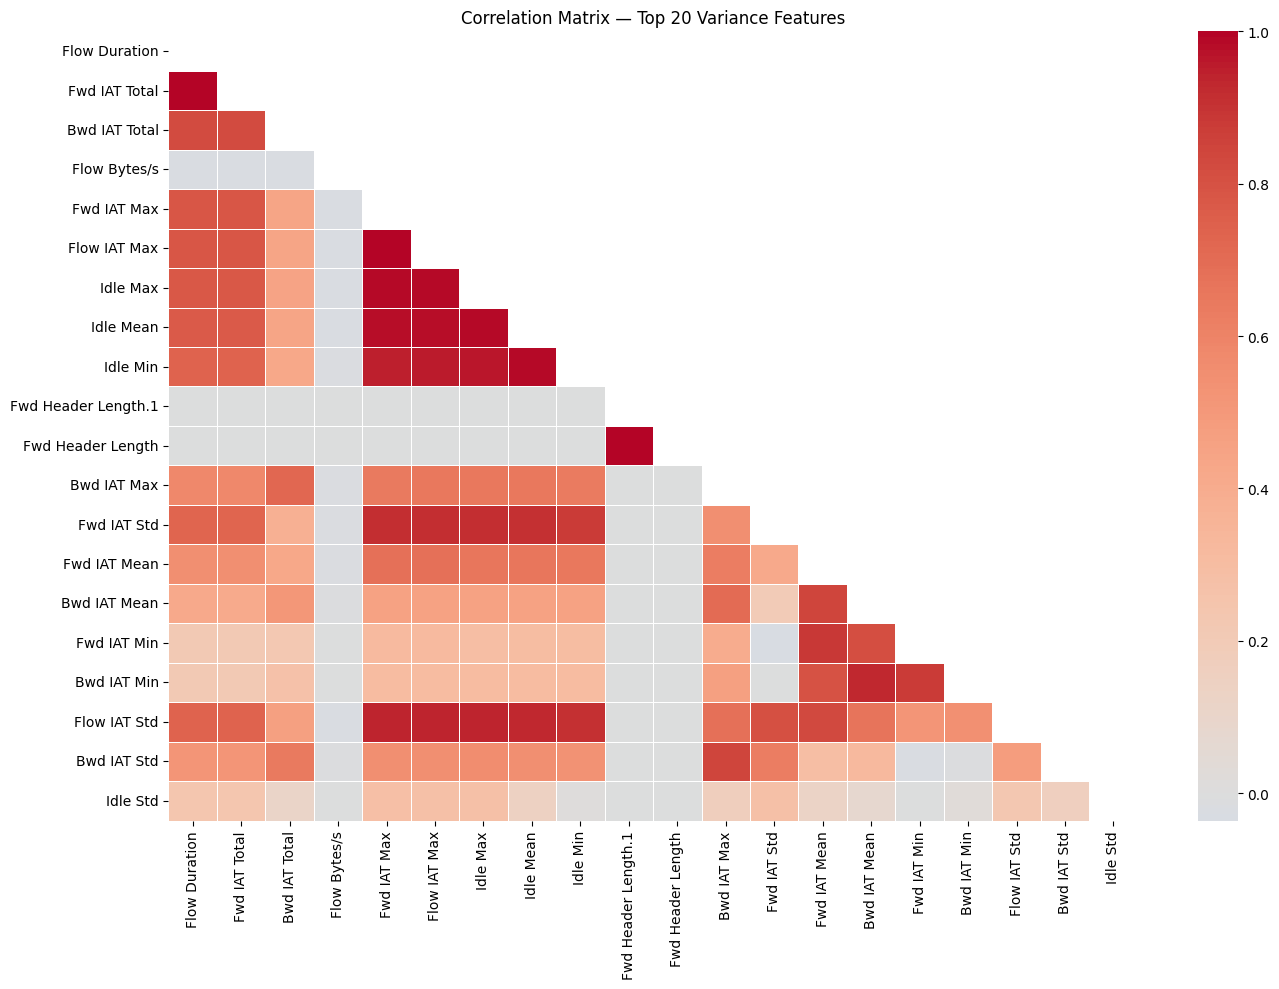

In [11]:
top_var_cols = df[numeric_cols].var().sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 10))
corr = df[top_var_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.5, annot=False)
plt.title('Correlation Matrix — Top 20 Variance Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## 8. Feature Distributions by Attack Type (Sample)

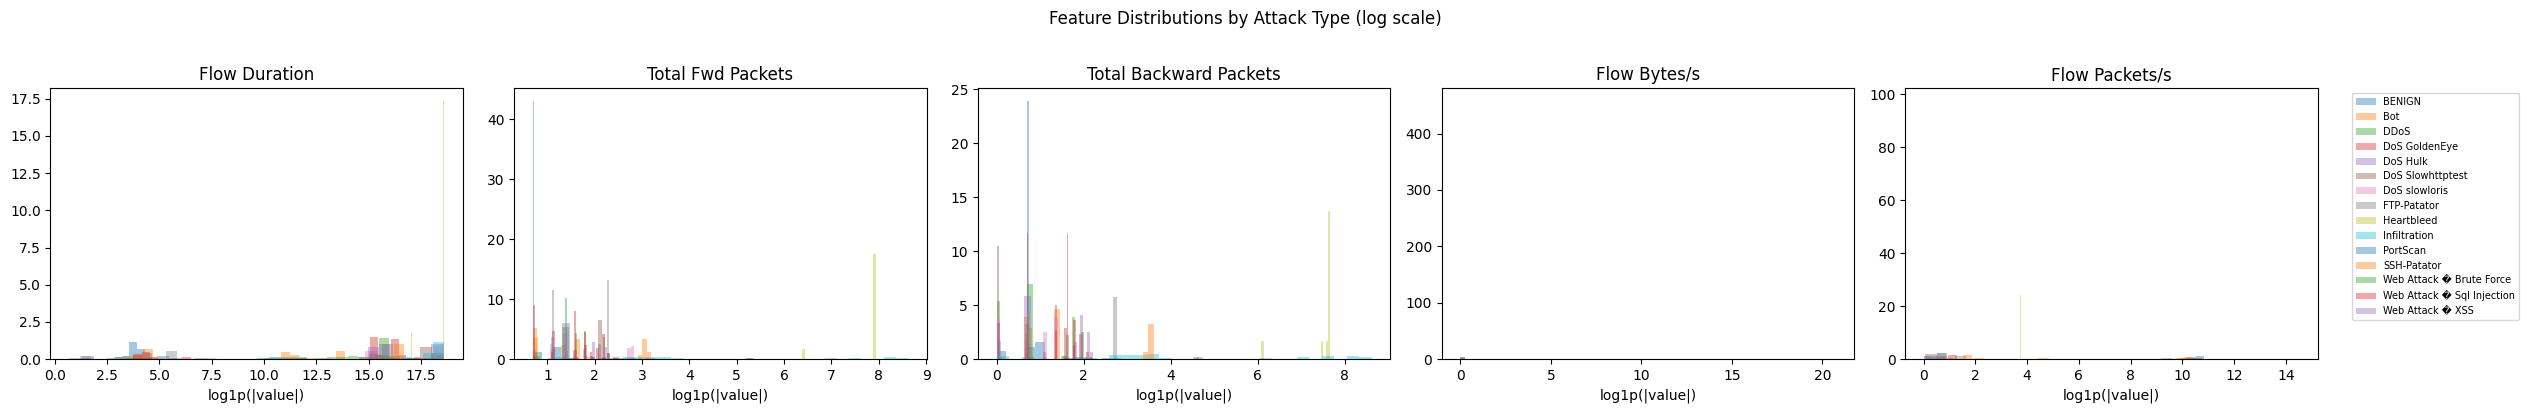

In [12]:
# pd.concat avoids pandas 2.x groupby Label-drop bug
sample = pd.concat([
    grp.sample(min(500, len(grp)), random_state=42)
    for _, grp in df.groupby('Label')
], ignore_index=True)

key_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'Flow Bytes/s', 'Flow Packets/s']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 4))

for ax, feat in zip(axes, key_features):
    for label in sample['Label'].unique():
        vals = sample[sample['Label'] == label][feat].dropna()
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            ax.hist(np.log1p(np.abs(vals)), bins=30, alpha=0.4, label=label, density=True)
    ax.set_title(feat)
    ax.set_xlabel('log1p(|value|)')

axes[-1].legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.5, 1))
plt.suptitle('Feature Distributions by Attack Type (log scale)', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Label Encoding

In [13]:
df['label_binary'] = (df['Label'] != 'BENIGN').astype(int)
print('Binary label distribution:')
print(df['label_binary'].value_counts())

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

print('\nClass mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i}: {cls}')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('\nLabel encoder saved → label_encoder.pkl')

Binary label distribution:
label_binary
0    2271320
1     556556
Name: count, dtype: int64

Class mapping:
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS

Label encoder saved → label_encoder.pkl


## 10. Feature Selection via Random Forest Importance

In [14]:
# pd.concat avoids pandas 2.x groupby Label-drop bug
sample_for_importance = pd.concat([
    grp.sample(min(2000, len(grp)), random_state=42)
    for _, grp in df.groupby('Label')
], ignore_index=True)

feature_cols = [c for c in numeric_cols if c not in ['label_binary', 'label_encoded']]
X_sample = sample_for_importance[feature_cols]
y_sample = sample_for_importance['label_encoded']

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_sample, y_sample)

importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(30)

print('Top 30 features by importance:')
print(top_features)

Top 30 features by importance:
Destination Port          0.0672
Init_Win_bytes_backward   0.0459
Bwd Packets/s             0.0330
Flow IAT Mean             0.0311
Init_Win_bytes_forward    0.0291
min_seg_size_forward      0.0270
Flow Packets/s            0.0227
Fwd Packets/s             0.0227
Flow IAT Max              0.0220
Flow IAT Std              0.0220
Fwd IAT Mean              0.0218
Packet Length Mean        0.0218
Flow Bytes/s              0.0210
Packet Length Std         0.0206
Max Packet Length         0.0204
Bwd Packet Length Min     0.0203
Fwd Packet Length Max     0.0203
Subflow Fwd Bytes         0.0196
Fwd IAT Total             0.0195
Fwd IAT Max               0.0195
Average Packet Size       0.0194
Avg Fwd Segment Size      0.0193
Fwd Packet Length Mean    0.0191
Bwd Header Length         0.0190
Avg Bwd Segment Size      0.0184
Bwd Packet Length Mean    0.0179
Packet Length Variance    0.0178
Fwd IAT Std               0.0162
Subflow Bwd Bytes         0.0155
Fwd Header L

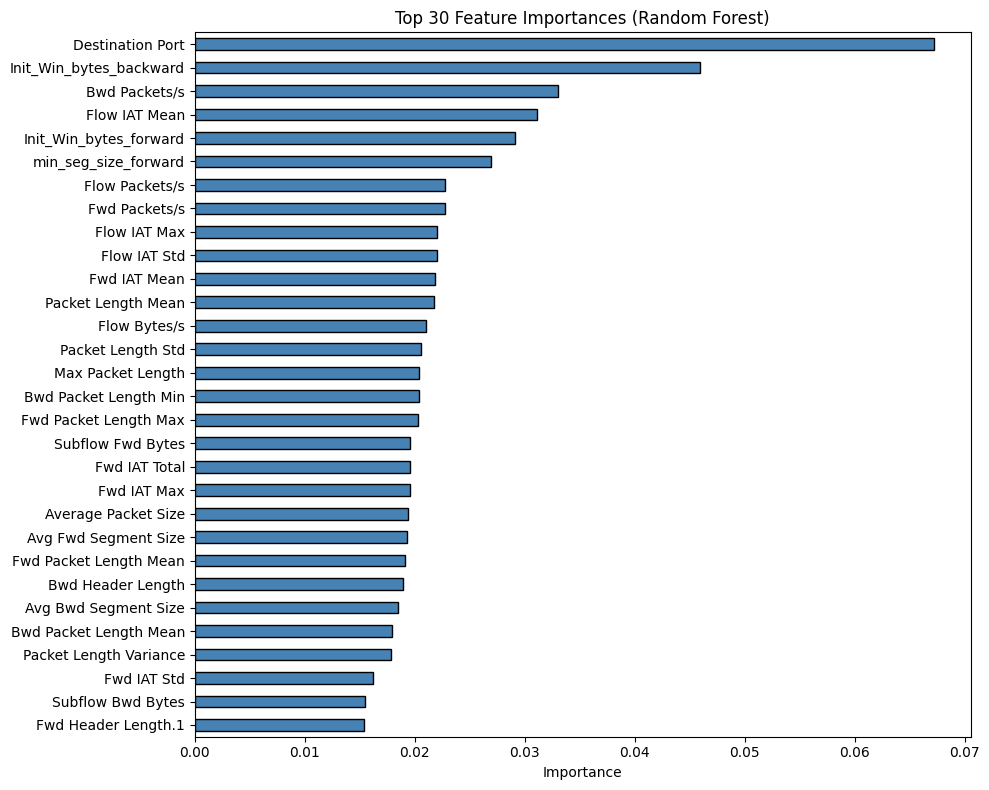

In [15]:
plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 30 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 11. Prepare Final Dataset

In [16]:
TOP_N = 30
selected_features = top_features.head(TOP_N).index.tolist()
print(f'Selected {TOP_N} features: {selected_features}')

X = df[selected_features].values
y_binary = df['label_binary'].values
y_multi  = df['label_encoded'].values

Selected 30 features: ['Destination Port', 'Init_Win_bytes_backward', 'Bwd Packets/s', 'Flow IAT Mean', 'Init_Win_bytes_forward', 'min_seg_size_forward', 'Flow Packets/s', 'Fwd Packets/s', 'Flow IAT Max', 'Flow IAT Std', 'Fwd IAT Mean', 'Packet Length Mean', 'Flow Bytes/s', 'Packet Length Std', 'Max Packet Length', 'Bwd Packet Length Min', 'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Fwd IAT Total', 'Fwd IAT Max', 'Average Packet Size', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Bwd Header Length', 'Avg Bwd Segment Size', 'Bwd Packet Length Mean', 'Packet Length Variance', 'Fwd IAT Std', 'Subflow Bwd Bytes', 'Fwd Header Length.1']


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved → scaler.pkl')

with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)
print('Feature list saved → selected_features.pkl')

Scaler saved → scaler.pkl
Feature list saved → selected_features.pkl


In [18]:
X_train, X_test, y_train_b, y_test_b, y_train_m, y_test_m = train_test_split(
    X_scaled, y_binary, y_multi,
    test_size=0.2, random_state=42, stratify=y_binary
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train attack ratio: {y_train_b.mean():.3f}')
print(f'Test  attack ratio: {y_test_b.mean():.3f}')

Train: (2262300, 30)  |  Test: (565576, 30)
Train attack ratio: 0.197
Test  attack ratio: 0.197


In [19]:
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train_binary.npy', y_train_b)
np.save('y_test_binary.npy', y_test_b)
np.save('y_train_multi.npy', y_train_m)
np.save('y_test_multi.npy', y_test_m)

print('All splits saved. Ready for Notebook 2.')

All splits saved. Ready for Notebook 2.


## Summary

| Step | Result |
|------|--------|
| Raw rows | ~2.8M |
| After cleaning | see above |
| Features selected | 30 (by RF importance) |
| Output files | `X_train.npy`, `X_test.npy`, `y_*`, `scaler.pkl`, `label_encoder.pkl`, `selected_features.pkl` |

**Next:** Notebook 2 — Model Training